# Deep Learning: Bidirectional GRU for Fake Review Detection

## 1. Introduction
While traditional Machine Learning models work well with frequency-based features, they often ignore the sequential nature of language. In this notebook, we implement a **Bidirectional GRU** model to capture context and long-term dependencies in reviews.

---


## 2. Environment Setup & Data Loading

We start by importing necessary libraries, setting a seed for reproducibility, and defining paths for data and model persistence. Unlike TF-IDF models, we perform tokenization and padding here.


In [1]:
import os
import pandas as pd
import joblib
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, Bidirectional, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Constants
RANDOM_STATE = 42
DATA_DIR = "../data/processed"
MODELS_DIR = "../models"
FIGURES_DIR = "../figures"
INPUT_PATH = "../data/preprocessed/cleaned_reviews.csv"

# Global Config
MAX_WORDS = 15000
EMBEDDING_DIM = 128

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Create directories if they don't exist
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# Set theme for plots
sns.set_theme(style="whitegrid")

print("Loading and tokenizing data...")
df = pd.read_csv(INPUT_PATH)
df['cleaned_review'] = df['cleaned_review'].fillna('')

X = df['cleaned_review']
y = df['label_binary']

# Determine MAX_LEN based on 95th percentile
review_lengths = [len(str(text).split()) for text in X]
MAX_LEN = int(np.percentile(review_lengths, 95))
print(f"95th percentile of review length: {MAX_LEN}")

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X)

X_seq = tokenizer.texts_to_sequences(X)
X_pad = pad_sequences(X_seq, maxlen=MAX_LEN, padding='post', truncating='post')


Loading and tokenizing data...
95th percentile of review length: 105


In [2]:
# Splitting: 80% Train/Val, 20% Test. Then 87.5% of Train/Val for Train (total 70% Train, 10% Val).
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_pad, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.125, random_state=RANDOM_STATE, stratify=y_train_val
)

print(f"Data split successfully:")
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Testing samples: {len(X_test)}")


Data split successfully:
Training samples: 28301
Validation samples: 4044
Testing samples: 8087


## 3. Model Building & Training

We define a Bidirectional GRU architecture and use callbacks like Early Stopping and Learning Rate reduction to optimize training.


In [3]:
model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(MAX_WORDS + 1, EMBEDDING_DIM),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001, verbose=1),
    ModelCheckpoint(os.path.join(MODELS_DIR, "best_deep_learning_model.keras"), 
                    monitor='val_loss', save_best_only=True, verbose=1)
]

print("Starting training...")
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 105, 128)       │     1,920,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,994,753 (7.61 MB)

 Trainable params: 1,994,753 (7.61 MB)

 Non-trainable params: 0 (0.00 B)

Starting training...
Epoch 1/15
443/443 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.7158 - loss: 0.4994
Epoch 1: val_loss improved from None to 0.25172, saving model to ../models\best_deep_learning_model.keras
443/443 ━━━━━━━━━━━━━━━━━━━━ 169s 320ms/step - accuracy: 0.8195 - loss: 0.3696 - val_accuracy: 0.8912 - val_loss: 0.2517 - learning_rate: 0.0010
Epoch 2/15
443/443 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.9159 - loss: 0.2026
Epoch 2: val_loss improved from 0.25172 to 0.23794, saving model to ../models\best_deep_learning_model.keras
443/443 ━━━━━━━━━━━━━━━━━━━━ 128s 289ms/step - accuracy: 0.9251 - loss: 0.1843 - val_accuracy: 0.8961 - val_loss: 0.2379 - learning_rate: 0.0010
Epoch 3/15
443/443 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.9470 - loss: 0.1365
Epoch 3: val_loss did not improve from 0.23794
443/443 ━━━━━━━━━━━━━━━━━━━━ 139s 283ms/step - accuracy: 0.9520 - loss: 0.1253 - val_accuracy: 0.8991 - val_loss: 0.2545 - learning_rate: 0.0010
Epoch 4/15
443/443

## 4. Model Evaluation

We evaluate the model on the unseen test set and calculate accuracy, ROC-AUC, and a detailed classification report.


In [4]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)
loss, acc = model.evaluate(X_test, y_test, verbose=0)
auc_score = roc_auc_score(y_test, y_pred_prob)

print(f"Test Accuracy: {acc:.4f}")
print(f"ROC-AUC Score: {auc_score:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Original (OR)', 'Computer Generated (CG)']))


253/253 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step
Test Accuracy: 0.9023
ROC-AUC Score: 0.9681

Classification Report:

                         precision    recall  f1-score   support

          Original (OR)       0.90      0.91      0.90      4044
Computer Generated (CG)       0.91      0.89      0.90      4043

               accuracy                           0.90      8087
              macro avg       0.90      0.90      0.90      8087
           weighted avg       0.90      0.90      0.90      8087



## 5. Visualizing Results

We visualize the model performance using a Confusion Matrix and training history plots.


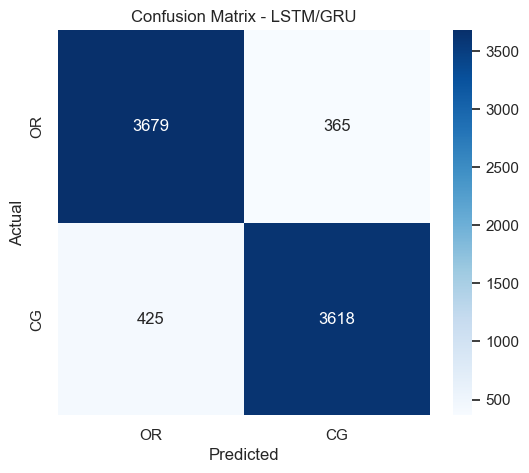

In [5]:
# 5.1. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['OR', 'CG'], yticklabels=['OR', 'CG'])
plt.title('Confusion Matrix - LSTM/GRU')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig(os.path.join(FIGURES_DIR, "dl_confusion_matrix.png"))
plt.show()


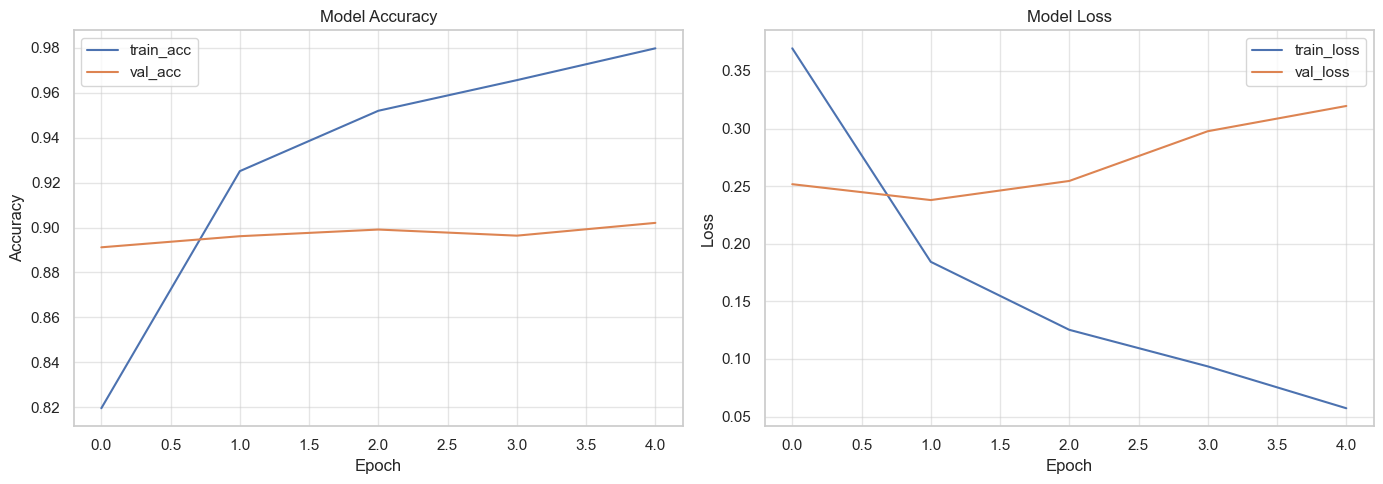

In [6]:
# 5.2. Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='train_acc')
ax1.plot(history.history['val_accuracy'], label='val_acc')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='train_loss')
ax2.plot(history.history['val_loss'], label='val_loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "dl_training_history.png"))
plt.show()


## 6. Model Persistence

Finally, we save the model, tokenizer, and metadata for future inference.


In [7]:
model.save(os.path.join(MODELS_DIR, "deep_learning_model.keras"))
joblib.dump(tokenizer, os.path.join(MODELS_DIR, "tokenizer.pkl"))

metadata = {
    "max_words": MAX_WORDS,
    "max_len": MAX_LEN,
    "embedding_dim": EMBEDDING_DIM,
    "test_accuracy": float(acc),
    "roc_auc": float(auc_score),
    "random_state": RANDOM_STATE
}

with open(os.path.join(MODELS_DIR, "deep_learning_metadata.json"), 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"Model and artifacts saved to: {MODELS_DIR}")


Model and artifacts saved to: ../models
